In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [11]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [ ]:
#Sample KNN model
knn_model = KNeighborsClassifier(n_neighbors = 11)
#train
knn_model.fit(X_train,y_train)
#test
y_pred_knn = knn_model.predict(X_test)

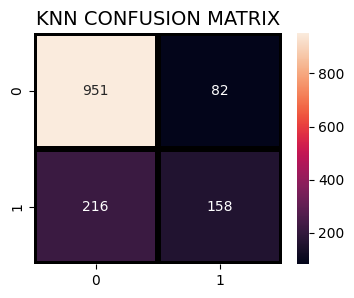

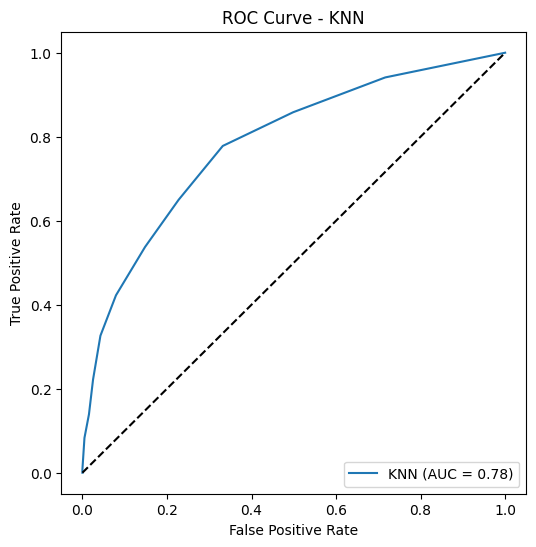

In [13]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("KNN CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.figure(figsize=(6,6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.show()


In [16]:
#Add Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Upgrade model
knn_model_new = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',   
    metric='manhattan'   
)

knn_model_new.fit(X_train_scaled, y_train)

y_pred = knn_model_new.predict(X_test_scaled)

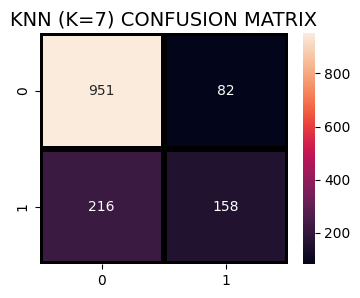

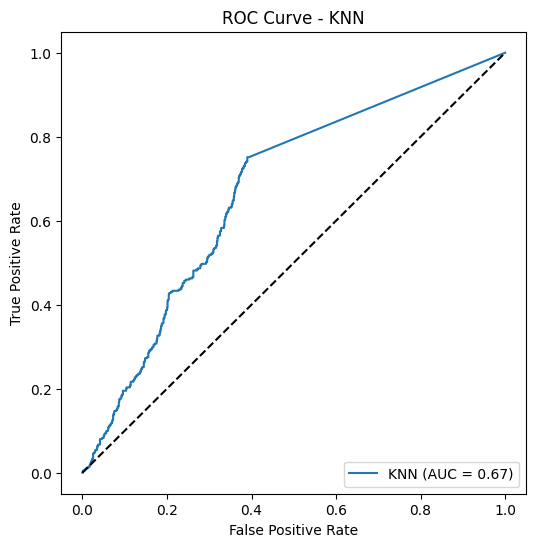

In [17]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("KNN (K=7) CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_knn = knn_model_new.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.figure(figsize=(6,6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.show()

In [18]:
#summary
data = {
    "Model": [
        "KNN (original K = 11)",
        "KNN (K = 7)"
    ],
    "TN": [951, 951],
    "FN": [82, 82],
    "FP": [216, 216],
    "TP": [158, 158]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,TN,FN,FP,TP
0,KNN (original K = 11),951,82,216,158
1,KNN (K = 7),951,82,216,158


In [19]:
data = {
    "Model": [
        "KNN (original K = 11)",
        "KNN (K = 7)"
    ],
    "Accuracy": [0.79, 0.79],
    "Precision": [0.82, 0.82],
    "Recall": [0.92, 0.92],
    "F1-score": [0.87, 0.87]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,Accuracy,Precision,Recall,F1-score
0,KNN (original K = 11),0.790000,0.820000,0.920000,0.870000
1,KNN (K = 7),0.790000,0.820000,0.920000,0.870000
